# Problem Statement

### Football clubs invest significant amounts in player transfers, making accurate player valuation critical for effective scouting and recruitment decisions. Traditional valuation methods often rely heavily on subjective judgment and market trends, which may lead to overpaying or missing undervalued talent.

### The objective of this project is to develop a machine learning model that estimates a fair transfer market value for football players using attributes such as age, overall rating, potential, technical skills, physical abilities, wages, and international reputation from FIFA player datasets.

### The model aims to support scouting and bidding decisions by providing data-driven player valuation insights that can help clubs identify suitable transfer targets and optimize recruitment budgets.

### Estimate a fair market transfer value for football players using player attributes

## Importing the necessary Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

## Importing the dataset

In [2]:
df_base = pd.read_csv(r"C:\Users\sujay\Desktop\data analytics\IBM Data Science\Next Steps\FIFA Dataset Project\male_players (legacy).csv")

C:\Users\sujay\AppData\Local\Temp\ipykernel_16584\981950958.py:1: DtypeWarning: Columns (108) have mixed types. Specify dtype option on import or set low_memory=False.
  df_base = pd.read_csv(r"C:\Users\sujay\Desktop\data analytics\IBM Data Science\Next Steps\FIFA Dataset Project\male_players (legacy).csv")


## Viewing the Dataset

In [3]:
df_base.head()

,player_id,player_url,fifa_version,fifa_update,fifa_update_date,short_name,long_name,player_positions,overall,potential,...,cdm,rdm,rwb,lb,lcb,cb,rcb,rb,gk,player_face_url
0,158023,/player/158023/lionel-messi/150002,15,2,2014-09-18,L. Messi,Lionel Andrés Messi Cuccittini,CF,93,95,...,62+3,62+3,62+3,54+3,45+3,45+3,45+3,54+3,15+3,https://cdn.sofifa.net/players/158/023/15_120.png
1,20801,/player/20801/c-ronaldo-dos-santos-aveiro/150002,15,2,2014-09-18,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,"LW, LM",92,92,...,63+3,63+3,63+3,57+3,52+3,52+3,52+3,57+3,16+3,https://cdn.sofifa.net/players/020/801/15_120.png
2,9014,/player/9014/arjen-robben/150002,15,2,2014-09-18,A. Robben,Arjen Robben,"RM, LM, RW",90,90,...,64+3,64+3,64+3,55+3,46+3,46+3,46+3,55+3,14+3,https://cdn.sofifa.net/players/009/014/15_120.png
3,41236,/player/41236/zlatan-ibrahimovic/150002,15,2,2014-09-18,Z. Ibrahimović,Zlatan Ibrahimović,ST,90,90,...,65+3,65+3,61+3,56+3,55+3,55+3,55+3,56+3,17+3,https://cdn.sofifa.net/players/041/236/15_120.png
4,167495,/player/167495/manuel-neuer/150002,15,2,2014-09-18,M. Neuer,Manuel Peter Neuer,GK,90,90,...,40+3,40+3,36+3,36+3,38+3,38+3,38+3,36+3,87+3,https://cdn.sofifa.net/players/167/495/15_120.png


In [4]:
# Display column names
print(df_base.columns.tolist())
# df_base.columns.tolist()

['player_id', 'player_url', 'fifa_version', 'fifa_update', 'fifa_update_date', 'short_name', 'long_name', 'player_positions', 'overall', 'potential', 'value_eur', 'wage_eur', 'age', 'dob', 'height_cm', 'weight_kg', 'league_id', 'league_name', 'league_level', 'club_team_id', 'club_name', 'club_position', 'club_jersey_number', 'club_loaned_from', 'club_joined_date', 'club_contract_valid_until_year', 'nationality_id', 'nationality_name', 'nation_team_id', 'nation_position', 'nation_jersey_number', 'preferred_foot', 'weak_foot', 'skill_moves', 'international_reputation', 'work_rate', 'body_type', 'real_face', 'release_clause_eur', 'player_tags', 'player_traits', 'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic', 'attacking_crossing', 'attacking_finishing', 'attacking_heading_accuracy', 'attacking_short_passing', 'attacking_volleys', 'skill_dribbling', 'skill_curve', 'skill_fk_accuracy', 'skill_long_passing', 'skill_ball_control', 'movement_acceleration', 'movement_sprint_sp

In [5]:
df_base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161583 entries, 0 to 161582
Columns: 110 entries, player_id to player_face_url
dtypes: float64(18), int64(45), object(47)
memory usage: 135.6+ MB


In [6]:
df_base.describe()

,player_id,fifa_version,fifa_update,overall,potential,value_eur,wage_eur,age,height_cm,weight_kg,...,mentality_composure,defending_marking_awareness,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,goalkeeping_speed
count,161583.000000,161583.000000,161583.0,161583.000000,161583.000000,1.595300e+05,159822.000000,161583.000000,161583.000000,161583.000000,...,128722.000000,161583.000000,161583.000000,161583.000000,161583.00000,161583.000000,161583.000000,161583.000000,161583.000000,17969.000000
mean,214484.722353,19.125514,2.0,65.699071,70.744008,2.326770e+06,10855.409768,25.123181,181.240205,75.235031,...,57.816892,45.757957,47.669996,45.698588,16.52961,16.274918,16.140374,16.288861,16.636973,39.149090
std,34928.608856,2.559318,0.0,7.040855,6.259121,6.005746e+06,21941.656285,4.670207,6.750148,7.000456,...,12.329739,20.453699,21.336404,20.935273,17.67047,16.834294,16.476466,16.998697,17.980143,10.503788
min,2.000000,15.000000,2.0,40.000000,40.000000,1.000000e+03,500.000000,16.000000,154.000000,49.000000,...,3.000000,1.000000,2.000000,3.000000,1.00000,1.000000,1.000000,1.000000,1.000000,12.000000
25%,199159.000000,17.000000,2.0,61.000000,66.000000,3.250000e+05,2000.000000,21.000000,176.000000,70.000000,...,50.000000,26.000000,27.000000,25.000000,8.00000,8.000000,8.000000,8.000000,8.000000,31.000000
50%,220621.000000,19.000000,2.0,66.000000,70.000000,7.250000e+05,4000.000000,25.000000,181.000000,75.000000,...,59.000000,50.000000,54.000000,52.000000,11.00000,11.000000,11.000000,11.000000,11.000000,41.000000
75%,236958.000000,21.000000,2.0,70.000000,75.000000,1.800000e+06,10000.000000,28.000000,186.000000,80.000000,...,66.000000,63.000000,66.000000,64.000000,14.00000,14.000000,14.000000,14.000000,14.000000,46.000000
max,271817.000000,23.000000,2.0,94.000000,95.000000,1.940000e+08,575000.000000,54.000000,208.000000,110.000000,...,96.000000,94.000000,94.000000,95.000000,91.00000,92.000000,95.000000,92.000000,94.000000,68.000000


## Picking out reqd columns as per Transfer Market Wage dependent context

In [7]:
df_base_reqd = df_base[['player_id', 'fifa_version', 'short_name', 'long_name', 
'player_positions', 'overall', 'potential', 'value_eur', 'wage_eur', 
'age', 'league_id', 'league_name', 'league_level', 
'club_team_id', 'club_name', 'club_position', 
'club_contract_valid_until_year', 'nationality_id', 'nationality_name', 
'international_reputation', 'work_rate', 'body_type']]

In [8]:
df_base_reqd.head(2)

,player_id,fifa_version,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,age,...,league_level,club_team_id,club_name,club_position,club_contract_valid_until_year,nationality_id,nationality_name,international_reputation,work_rate,body_type
0,158023,15,L. Messi,Lionel Andrés Messi Cuccittini,CF,93,95,100500000.0,550000.0,27,...,1.0,241.0,FC Barcelona,CF,2018.0,52,Argentina,5,Medium/Low,Normal (170-)
1,20801,15,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,"LW, LM",92,92,79000000.0,375000.0,29,...,1.0,243.0,Real Madrid CF,LW,2018.0,38,Portugal,5,High/Low,Normal (185+)


In [9]:
df_base_reqd[df_base_reqd['player_id'] == 158023][['short_name']]

,short_name
0,L. Messi
16182,L. Messi
32862,L. Messi
50428,L. Messi
68356,L. Messi
86441,L. Messi
104924,L. Messi
123811,L. Messi
143050,L. Messi


In [10]:
## one player may have multiple posn which can change over time
df_base_reqd[df_base_reqd['player_id'] == 158023][['short_name','player_positions']]

,short_name,player_positions
0,L. Messi,CF
16182,L. Messi,"RW, CF"
32862,L. Messi,RW
50428,L. Messi,RW
68356,L. Messi,"CF, RW, ST"
86441,L. Messi,"RW, CF, ST"
104924,L. Messi,"RW, ST, CF"
123811,L. Messi,"RW, ST, CF"
143050,L. Messi,RW


## Data Cleaning

In [11]:
df_base_reqd.select_dtypes(include=int).columns

Index(['player_id', 'fifa_version', 'overall', 'potential', 'age',
       'nationality_id', 'international_reputation'],
      dtype='object')

In [12]:
df_base_reqd.select_dtypes(include='object').columns

Index(['short_name', 'long_name', 'player_positions', 'league_name',
       'club_name', 'club_position', 'nationality_name', 'work_rate',
       'body_type'],
      dtype='object')

In [13]:
# print(df_base[df_base['player_id'].isna()])
# print(df_base[df_base['player_id'].isnull()])
df_base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161583 entries, 0 to 161582
Columns: 110 entries, player_id to player_face_url
dtypes: float64(18), int64(45), object(47)
memory usage: 135.6+ MB


In [14]:
missing_values = [
    '', ' ', 'NA', 'N/A', 'na', 'null', 'NULL',
    'None', 'none', '-', '--','NaN'
]

### Checking which all columns has NaN

In [15]:
for column_name in df_base_reqd.columns:
    # print(column_name)
    na_count = df_base_reqd[column_name].isna().sum()
    pct_missing = np.divide(na_count,len(df_base_reqd[column_name]))
    print(f'{column_name} has na count of :{na_count} with % missing as {np.round(pct_missing*100,2)}%')

player_id has na count of :0 with % missing as 0.0%
fifa_version has na count of :0 with % missing as 0.0%
short_name has na count of :0 with % missing as 0.0%
long_name has na count of :0 with % missing as 0.0%
player_positions has na count of :0 with % missing as 0.0%
overall has na count of :0 with % missing as 0.0%
potential has na count of :0 with % missing as 0.0%
value_eur has na count of :2053 with % missing as 1.27%
wage_eur has na count of :1761 with % missing as 1.09%
age has na count of :0 with % missing as 0.0%
league_id has na count of :1773 with % missing as 1.1%
league_name has na count of :1773 with % missing as 1.1%
league_level has na count of :2717 with % missing as 1.68%
club_team_id has na count of :1773 with % missing as 1.1%
club_name has na count of :1773 with % missing as 1.1%
club_position has na count of :1773 with % missing as 1.1%
club_contract_valid_until_year has na count of :1773 with % missing as 1.1%
nationality_id has na count of :0 with % missing as

In [16]:
df_base_reqd = df_base_reqd.dropna(subset=['value_eur'])

In [17]:
for column_name in df_base_reqd.columns:
    # print(column_name)
    na_count = df_base_reqd[column_name].isna().sum()
    pct_missing = np.divide(na_count,len(df_base_reqd[column_name]))
    print(f'{column_name} has na count of :{na_count} with % missing as {np.round(pct_missing*100,2)}%')

player_id has na count of :0 with % missing as 0.0%
fifa_version has na count of :0 with % missing as 0.0%
short_name has na count of :0 with % missing as 0.0%
long_name has na count of :0 with % missing as 0.0%
player_positions has na count of :0 with % missing as 0.0%
overall has na count of :0 with % missing as 0.0%
potential has na count of :0 with % missing as 0.0%
value_eur has na count of :0 with % missing as 0.0%
wage_eur has na count of :0 with % missing as 0.0%
age has na count of :0 with % missing as 0.0%
league_id has na count of :12 with % missing as 0.01%
league_name has na count of :12 with % missing as 0.01%
league_level has na count of :949 with % missing as 0.59%
club_team_id has na count of :12 with % missing as 0.01%
club_name has na count of :12 with % missing as 0.01%
club_position has na count of :12 with % missing as 0.01%
club_contract_valid_until_year has na count of :12 with % missing as 0.01%
nationality_id has na count of :0 with % missing as 0.0%
nationali

In [18]:
# df_base_reqd[['league_name','league_level']].drop_duplicates()

In [19]:
df_base_reqd['league_name'] = df_base_reqd['league_name'].fillna('Not Specified')
df_base_reqd['league_level'] = df_base_reqd['league_level'].fillna(5)
df_base_reqd['club_team_id'] = df_base_reqd['club_team_id'].fillna('Not Specified')
df_base_reqd['club_name'] = df_base_reqd['club_name'].fillna('Not Specified')
df_base_reqd['club_position'] = df_base_reqd['club_position'].fillna('Not Specified')
df_base_reqd['club_contract_valid_until_year'] = df_base_reqd['club_contract_valid_until_year'].fillna('Not Specified')
# df_base_reqd['league_name'].isna().sum()

In [20]:
for column_name in df_base_reqd.columns:
    # print(column_name)
    na_count = df_base_reqd[column_name].isna().sum()
    pct_missing = np.divide(na_count,len(df_base_reqd[column_name]))
    print(f'{column_name} has na count of :{na_count} with % missing as {np.round(pct_missing*100,2)}%')

player_id has na count of :0 with % missing as 0.0%
fifa_version has na count of :0 with % missing as 0.0%
short_name has na count of :0 with % missing as 0.0%
long_name has na count of :0 with % missing as 0.0%
player_positions has na count of :0 with % missing as 0.0%
overall has na count of :0 with % missing as 0.0%
potential has na count of :0 with % missing as 0.0%
value_eur has na count of :0 with % missing as 0.0%
wage_eur has na count of :0 with % missing as 0.0%
age has na count of :0 with % missing as 0.0%
league_id has na count of :12 with % missing as 0.01%
league_name has na count of :0 with % missing as 0.0%
league_level has na count of :0 with % missing as 0.0%
club_team_id has na count of :0 with % missing as 0.0%
club_name has na count of :0 with % missing as 0.0%
club_position has na count of :0 with % missing as 0.0%
club_contract_valid_until_year has na count of :0 with % missing as 0.0%
nationality_id has na count of :0 with % missing as 0.0%
nationality_name has n

### Checking for special characters, white space, blanks etc

In [21]:
for column_name in df_base_reqd.columns:
    print(f'{column_name} has {df_base_reqd[column_name].isin(missing_values).sum()} special characters or blanks')

player_id has 0 special characters or blanks
fifa_version has 0 special characters or blanks
short_name has 0 special characters or blanks
long_name has 0 special characters or blanks
player_positions has 0 special characters or blanks
overall has 0 special characters or blanks
potential has 0 special characters or blanks
value_eur has 0 special characters or blanks
wage_eur has 0 special characters or blanks
age has 0 special characters or blanks
league_id has 0 special characters or blanks
league_name has 0 special characters or blanks
league_level has 0 special characters or blanks
club_team_id has 0 special characters or blanks
club_name has 0 special characters or blanks
club_position has 0 special characters or blanks
club_contract_valid_until_year has 0 special characters or blanks
nationality_id has 0 special characters or blanks
nationality_name has 0 special characters or blanks
international_reputation has 0 special characters or blanks
work_rate has 0 special characters or 

## EDA

In [22]:
df_base_reqd.columns

Index(['player_id', 'fifa_version', 'short_name', 'long_name',
       'player_positions', 'overall', 'potential', 'value_eur', 'wage_eur',
       'age', 'league_id', 'league_name', 'league_level', 'club_team_id',
       'club_name', 'club_position', 'club_contract_valid_until_year',
       'nationality_id', 'nationality_name', 'international_reputation',
       'work_rate', 'body_type'],
      dtype='object')

In [23]:
## top 10 players with highest market value in 2023
df_top10_valued_players_2023 = df_base_reqd[df_base_reqd['fifa_version']==23][['short_name','value_eur']].sort_values(by='value_eur',ascending=False).head(5)

In [24]:
df_top10_valued_players_2023

,short_name,value_eur
143054,K. Mbappé,190500000.0
143078,E. Haaland,148000000.0
143090,F. de Jong,116500000.0
143140,Pedri,116000000.0
143059,M. Salah,115500000.0


<Axes: xlabel='short_name', ylabel='value_eur'>

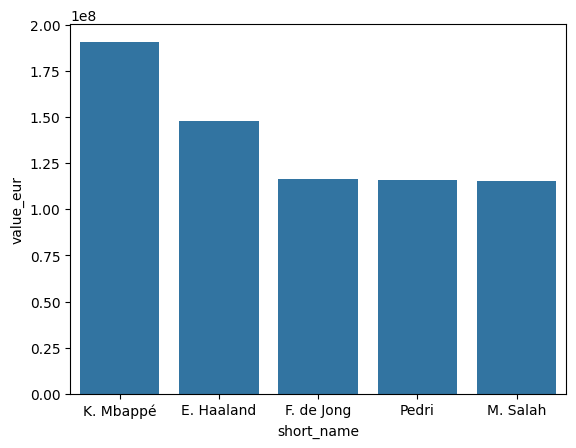

In [25]:
sns.barplot(data=df_top10_valued_players_2023,x='short_name',y='value_eur')

In [26]:
## max players by nationality
df_player_ct_by_nationality = df_base_reqd['nationality_name'].value_counts().reset_index().head(5)

Text(0, 0.5, 'Player count')

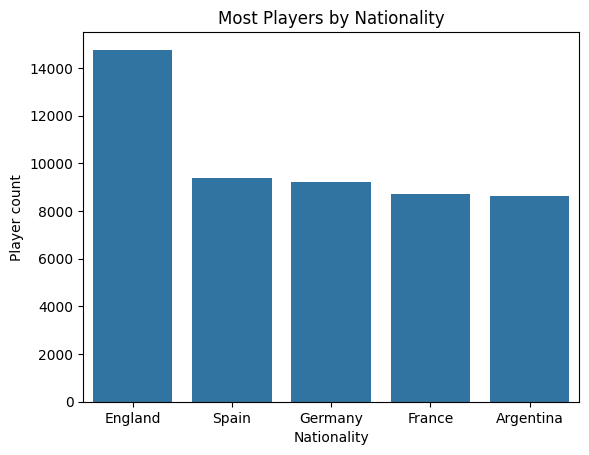

In [27]:
sns.barplot(data=df_player_ct_by_nationality,x='nationality_name',y='count')
plt.title('Most Players by Nationality')
plt.xlabel('Nationality')
plt.ylabel('Player count')

In [28]:
df_age_count =df_base_reqd['age'].value_counts().reset_index()
df_age_count=df_age_count.sort_values(by='count',ascending=False).head(20)

<Axes: title={'center': 'Top Number of players by Age'}, xlabel='age', ylabel='count'>

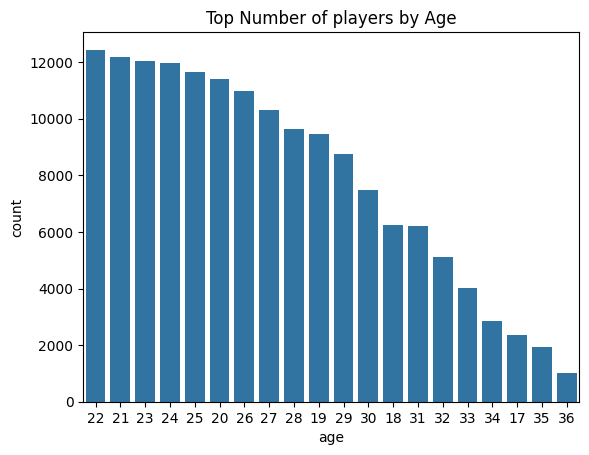

In [29]:
plt.title('Top Number of players by Age')
sns.barplot(data=df_age_count,x=df_age_count['age'].astype('str'),y='count')

In [30]:
player_posn_count = df_base_reqd['player_positions'].value_counts().reset_index()
player_posn_count = player_posn_count.sort_values(by='count',ascending=False).head(10)

<Axes: title={'center': 'Top 10 Positions'}, xlabel='Positions', ylabel='Number of players'>

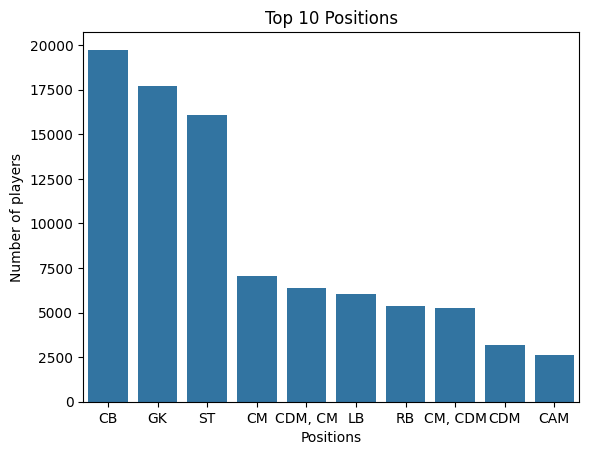

In [31]:
## Top 10 positions
plt.title('Top 10 Positions')
plt.xlabel('Positions')
plt.ylabel('Number of players')
sns.barplot(data=player_posn_count,x='player_positions',y='count')
# df_base_reqd['player_id'].count()

In [32]:
df_base_reqd[df_base_reqd['fifa_version']==16]['player_id'].count()

16379

<Axes: title={'center': 'Number of players per FIFA year'}, xlabel='Years', ylabel='Number of players'>

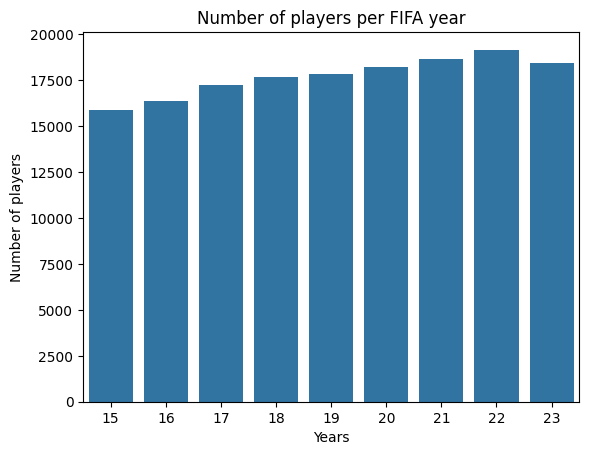

In [33]:
## Number of players per year
year_counts = []

for year in df_base_reqd['fifa_version'].drop_duplicates():
    player_counts_per_yr = df_base_reqd[df_base_reqd['fifa_version']==year]['player_id'].count()
    year_counts.append([year,player_counts_per_yr])

year_counts_df = pd.DataFrame(data=year_counts,columns=['year','player_counts_per_yr'])

plt.title('Number of players per FIFA year')
plt.xlabel('Years')
plt.ylabel('Number of players')
sns.barplot(data=year_counts_df,x='year',y='player_counts_per_yr')

## Feature Engineering

In [34]:
## 1.Potential Gap
df_base_reqd['potential gap'] = df_base_reqd['potential'] - df_base_reqd['overall']

In [35]:
## 2. Age Buckets
df_base_reqd['Age_buckets'] = pd.cut(df_base_reqd['age'],bins=[15,20,25,30,35,45],labels=['16-20','21-25','26-30','31-35','36+'])

In [36]:
df_base_reqd['player_positions'].drop_duplicates()

0                   CF
1               LW, LM
2           RM, LM, RW
3                   ST
4                   GK
              ...     
159623     LM, CB, LWB
159667     RWB, ST, CM
160269    CB, LWB, CDM
160571      CM, RW, RB
160899    CM, CAM, LWB
Name: player_positions, Length: 1966, dtype: object

In [37]:
df_base_reqd['primary_position'] = (
    df_base_reqd['player_positions']
    .str.split(',')
    .str[0]
    .str.strip()
)

In [38]:
def position_classification(pos):
    if pos in ('CF','ST','LW','RW'):
        return 'Forward'
    elif pos in ('RM','CM','LM','CDM','CAM'):
        return'Midfielder'
    elif pos in ('CB','RB','LB','LWB','RWB'):
        return 'Defender'
    elif pos == 'GK':
        return 'Goalkeeper'
    else:
        return 'check'
        
# position_classification('GK')

In [39]:
df_base_reqd['aggregated_primary_posn']=df_base_reqd['primary_position'].apply(position_classification)
df_base_reqd[['primary_position','aggregated_primary_posn']].drop_duplicates().sort_values(by='aggregated_primary_posn')

,primary_position,aggregated_primary_posn
13,CB,Defender
73,RB,Defender
119,LB,Defender
1319,LWB,Defender
2069,RWB,Defender
0,CF,Forward
1,LW,Forward
3,ST,Forward
62,RW,Forward
4,GK,Goalkeeper


In [40]:
df_reqd_2023 = df_base_reqd[df_base_reqd['fifa_version']==23]

In [41]:
df_reqd_2023.drop(columns=['player_id','fifa_version','player_positions','league_id','league_name','club_team_id','club_name'
,'club_position','nationality_id','primary_position','age'],inplace=True)

C:\Users\sujay\AppData\Local\Temp\ipykernel_16584\2421681707.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_reqd_2023.drop(columns=['player_id','fifa_version','player_positions','league_id','league_name','club_team_id','club_name'


In [42]:
df_reqd_2023.columns

Index(['short_name', 'long_name', 'overall', 'potential', 'value_eur',
       'wage_eur', 'league_level', 'club_contract_valid_until_year',
       'nationality_name', 'international_reputation', 'work_rate',
       'body_type', 'potential gap', 'Age_buckets', 'aggregated_primary_posn'],
      dtype='object')

## Heatmap to understand relationship between input and target variable

<Axes: >

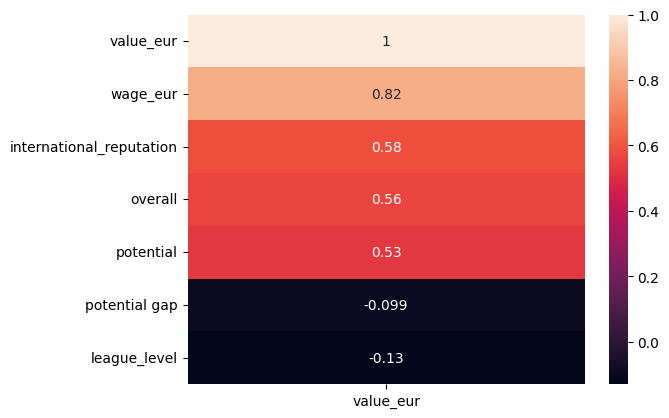

In [43]:
sns.heatmap(df_reqd_2023.select_dtypes(include=['float','int']).corr()[['value_eur']].sort_values(by='value_eur',ascending=False),annot=True)

## Using Log transform of target variable to get unfiorm distribution

<Axes: xlabel='value_eur', ylabel='Count'>

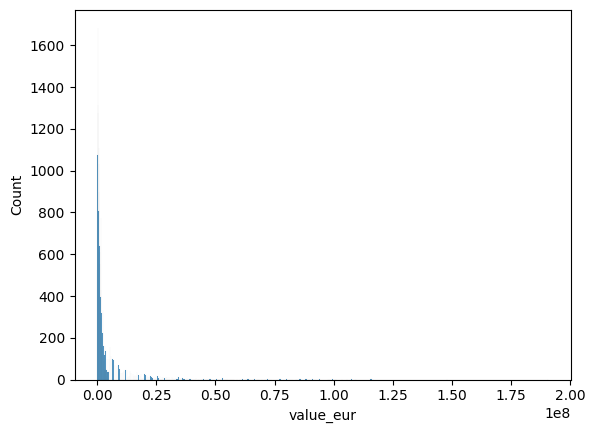

In [44]:
sns.histplot(data=df_reqd_2023,x=df_reqd_2023['value_eur'])

<Axes: xlabel='value_eur', ylabel='Count'>

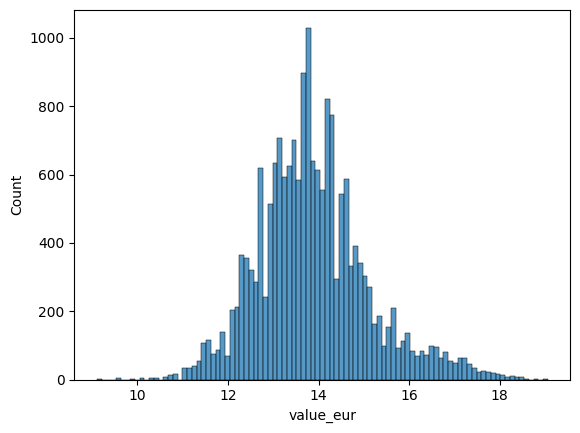

In [45]:
sns.histplot(data=df_reqd_2023,x=np.log1p(df_reqd_2023['value_eur']))

<Axes: xlabel='wage_eur', ylabel='Count'>

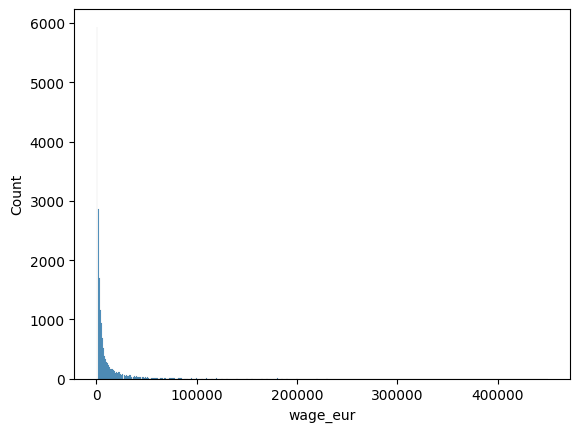

In [46]:
sns.histplot(data=df_reqd_2023,x=df_reqd_2023['wage_eur'])

<Axes: xlabel='wage_eur', ylabel='Count'>

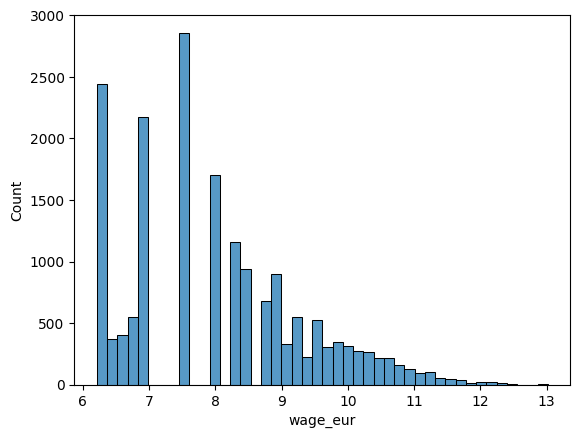

In [47]:
sns.histplot(data=df_reqd_2023,x=np.log1p(df_reqd_2023['wage_eur']))

In [48]:
## Creating log transfomed columns for wage_eur and value_eur
df_reqd_2023['log_transformed_wages'] = np.log1p(df_reqd_2023['wage_eur'])
df_reqd_2023['log_transformed_value_eur'] = np.log1p(df_reqd_2023['value_eur'])

C:\Users\sujay\AppData\Local\Temp\ipykernel_16584\2746058877.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_reqd_2023['log_transformed_wages'] = np.log1p(df_reqd_2023['wage_eur'])
C:\Users\sujay\AppData\Local\Temp\ipykernel_16584\2746058877.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_reqd_2023['log_transformed_value_eur'] = np.log1p(df_reqd_2023['value_eur'])


In [49]:
df_reqd_2023.head(2)

,short_name,long_name,overall,potential,value_eur,wage_eur,league_level,club_contract_valid_until_year,nationality_name,international_reputation,work_rate,body_type,potential gap,Age_buckets,aggregated_primary_posn,log_transformed_wages,log_transformed_value_eur
143050,L. Messi,Lionel Andrés Messi Cuccittini,91,91,54000000.0,195000.0,1.0,2023.0,Argentina,5,Low/Low,Unique,0,31-35,Forward,12.180760,17.804495
143051,K. Benzema,Karim Benzema,91,91,64000000.0,450000.0,1.0,2023.0,France,4,Medium/Medium,Normal (170-185),0,31-35,Forward,13.017005,17.974394


In [50]:
df_reqd_2023_log_added = df_reqd_2023.drop(columns=['value_eur','wage_eur','short_name','long_name','potential gap'])

In [51]:
df_reqd_2023_log_added.columns

Index(['overall', 'potential', 'league_level',
       'club_contract_valid_until_year', 'nationality_name',
       'international_reputation', 'work_rate', 'body_type', 'Age_buckets',
       'aggregated_primary_posn', 'log_transformed_wages',
       'log_transformed_value_eur'],
      dtype='object')

In [52]:
df_reqd_2023_log_added['league_level'].drop_duplicates()

143050    1.0
143440    2.0
146016    3.0
150340    4.0
150488    5.0
Name: league_level, dtype: float64

## Modeling

### 1. Multiple Linear Regression

In [53]:
df_reqd_2023_log_added['club_contract_valid_until_year'] = df_reqd_2023_log_added['club_contract_valid_until_year'].astype(float).astype(int)

In [54]:
df_reqd_2023_log_added.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18444 entries, 143050 to 161582
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   overall                         18444 non-null  int64   
 1   potential                       18444 non-null  int64   
 2   league_level                    18444 non-null  float64 
 3   club_contract_valid_until_year  18444 non-null  int32   
 4   nationality_name                18444 non-null  object  
 5   international_reputation        18444 non-null  int64   
 6   work_rate                       18444 non-null  object  
 7   body_type                       18444 non-null  object  
 8   Age_buckets                     18444 non-null  category
 9   aggregated_primary_posn         18444 non-null  object  
 10  log_transformed_wages           18444 non-null  float64 
 11  log_transformed_value_eur       18444 non-null  float64 
dtypes: category(1), f

In [55]:
## Lets check the categorical features
catg_columns = df_reqd_2023_log_added.select_dtypes(include=['object','category']).columns.tolist()
catg_columns

['nationality_name',
 'work_rate',
 'body_type',
 'Age_buckets',
 'aggregated_primary_posn']

In [56]:
numerical_columns = df_reqd_2023_log_added.drop(columns = 'log_transformed_value_eur').select_dtypes(include=['int','float']).columns.tolist()
numerical_columns

['overall',
 'potential',
 'league_level',
 'club_contract_valid_until_year',
 'international_reputation',
 'log_transformed_wages']

In [57]:
X=df_reqd_2023_log_added.drop(columns='log_transformed_value_eur')

In [58]:
y=df_reqd_2023_log_added['log_transformed_value_eur']

In [59]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [60]:
## One hot encoding for categorical columns
preprocessor_onehot = ColumnTransformer(transformers=[('catg',OneHotEncoder(handle_unknown='ignore'),catg_columns)],remainder='passthrough')

In [61]:
pipeline = Pipeline([('preprocessor_onehot',preprocessor_onehot),('model_linear_reg',LinearRegression())])

In [62]:
pipeline.fit(X_train,y_train)

C:\Users\sujay\anaconda_Feb27_2025_latest\Lib\site-packages\sklearn\compose\_column_transformer.py:1651: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor_onehot',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('catg',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['nationality_name',
                                                   'work_rate', 'body_type',
                                                   'Age_buckets',
                                                   'aggregated_primary_posn'])])),
                ('model_linear_reg', LinearRegression())])

In [63]:
y_pred = pipeline.predict(X_test)

In [64]:
mae = round(mean_absolute_error(y_test,y_pred),2)
r2 = round(r2_score(y_test,y_pred),2)
print(f'mae is {mae} and r2 is {r2}')

mae is 0.15 and r2 is 0.97


### We can infer that model explains 97% of variance

## 2. Multiple Linear Regression without using value_eur

In [65]:
X=df_reqd_2023_log_added.drop(columns=['log_transformed_wages','log_transformed_value_eur'])
y=df_reqd_2023_log_added['log_transformed_value_eur']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
preprocessor_onehot = ColumnTransformer(transformers=[('catg',OneHotEncoder(handle_unknown='ignore'),catg_columns)],remainder='passthrough')
pipeline = Pipeline([('preprocessor_onehot',preprocessor_onehot),('MLR',LinearRegression())])
pipeline.fit(X_train,y_train)

C:\Users\sujay\anaconda_Feb27_2025_latest\Lib\site-packages\sklearn\compose\_column_transformer.py:1651: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor_onehot',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('catg',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['nationality_name',
                                                   'work_rate', 'body_type',
                                                   'Age_buckets',
                                                   'aggregated_primary_posn'])])),
                ('MLR', LinearRegression())])

In [66]:
y_pred = pipeline.predict(X_test)
mae = mean_absolute_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)
print(f'mae is {mae} and r2 score is {r2}')

mae is 0.1533630245550916 and r2 score is 0.9695280240874119


In [67]:
## Since we converted to log scale, its difficult to interpret MAE so convert back to normal Scale
actual_values = np.expm1(y_test)

predicted_values = np.expm1(y_pred)

In [68]:
mae_linear_reg = mean_absolute_error(actual_values,predicted_values)
r2_linear_reg = r2_score(actual_values,predicted_values)
print(f'mae is {mae_linear_reg} and r2 score is {r2_linear_reg}')

mae is 540430.4994592258 and r2 score is 0.9039527764935987


### On average, the model’s prediction is off by 540,000 Euros
### 90% of variance is explained by the model

In [69]:
540000/round(np.average(actual_values),0)

0.19789048740427048

### On average, the model’s prediction error is about 20% of the average player market value.

## 2. Random Forest

In [70]:
preprocessor_onehot = ColumnTransformer(transformers=[('catg',OneHotEncoder(handle_unknown='ignore'),catg_columns)],remainder='passthrough')

In [71]:
pipeline = Pipeline([('preprocessor_onehot',preprocessor_onehot),('RF',RandomForestRegressor(random_state=42))])

In [72]:
pipeline.fit(X_train,y_train)

C:\Users\sujay\anaconda_Feb27_2025_latest\Lib\site-packages\sklearn\compose\_column_transformer.py:1651: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor_onehot',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('catg',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['nationality_name',
                                                   'work_rate', 'body_type',
                                                   'Age_buckets',
                                                   'aggregated_primary_posn'])])),
                ('RF', RandomForestRegressor(random_state=42))])

In [73]:
y_pred = pipeline.predict(X_test)

In [74]:
## Convert from Log to actual values
actual_values = np.expm1(y_test)
pred_value = np.expm1(y_pred)

In [75]:
mae_rf = mean_absolute_error(actual_values,pred_value)
r2_rf = r2_score(actual_values,pred_value)
print(f'MAE is {mae_rf} and r2s score is {r2_rf}')

MAE is 209529.539864488 and r2s score is 0.9702223073565351


### The model is now off by only about €210,000 on average

## 3. XGBoost

In [76]:
pipeline = Pipeline([('preprocessor',preprocessor_onehot),('XGB',XGBRegressor(random_state=42))])

In [77]:
pipeline.fit(X_train,y_train)

C:\Users\sujay\anaconda_Feb27_2025_latest\Lib\site-packages\sklearn\compose\_column_transformer.py:1651: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('catg',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['nationality_name',
                                                   'work_rate', 'body_type',
                                                   'Age_buckets',
                                                   'aggregated_primary_posn'])])),
                ('XGB',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsample_bytree=...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=None, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [78]:
y_pred_log = pipeline.predict(X_test)

In [79]:
## Converting from log values to actuals
actual_values = np.expm1(y_test)
predicted_values = np.expm1(y_pred_log)

In [80]:
mae_xgb = mean_absolute_error(actual_values,predicted_values)
r2_xgb = r2_score(actual_values,predicted_values)
print(f'MAE is {mae} and r2score is {r2}')

MAE is 0.1533630245550916 and r2score is 0.9695280240874119


## Summary

In [81]:
mae_linear_reg = int(mae_linear_reg)
mae_rf = int(mae_rf)
mae_xgb = int(mae_xgb)
r2_linear_reg 
r2_rf 
r2_xgb 

0.9809092227797421

In [82]:
summary = pd.DataFrame({'Model':['Linear Regression','Random Forest','XGBoost'],'MAE':[mae_linear_reg,mae_rf,mae_xgb],'R2':[r2_linear_reg,r2_rf,r2_xgb]})
summary

,Model,MAE,R2
0,Linear Regression,540430,0.903953
1,Random Forest,209529,0.970222
2,XGBoost,219232,0.980909


## Feature Importance

In [83]:
xgb_model = pipeline.named_steps['XGB']
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()
importance_df = pd.DataFrame({'Feature':feature_names,'importance':xgb_model.feature_importances_})
importance_df = importance_df.sort_values(by='importance',ascending=False)
importance_df.head(10)

,Feature,importance
184,remainder__overall,0.493528
185,remainder__potential,0.173176
179,catg__Age_buckets_36+,0.111553
177,catg__Age_buckets_26-30,0.067669
182,catg__aggregated_primary_posn_Goalkeeper,0.031453
178,catg__Age_buckets_31-35,0.013159
176,catg__Age_buckets_21-25,0.007213
180,catg__aggregated_primary_posn_Defender,0.005939
16,catg__nationality_name_Bolivia,0.004458
181,catg__aggregated_primary_posn_Forward,0.003716


<Axes: title={'center': 'Top 5 features by importance in XGBoost Model'}, xlabel='Feature', ylabel='importance'>

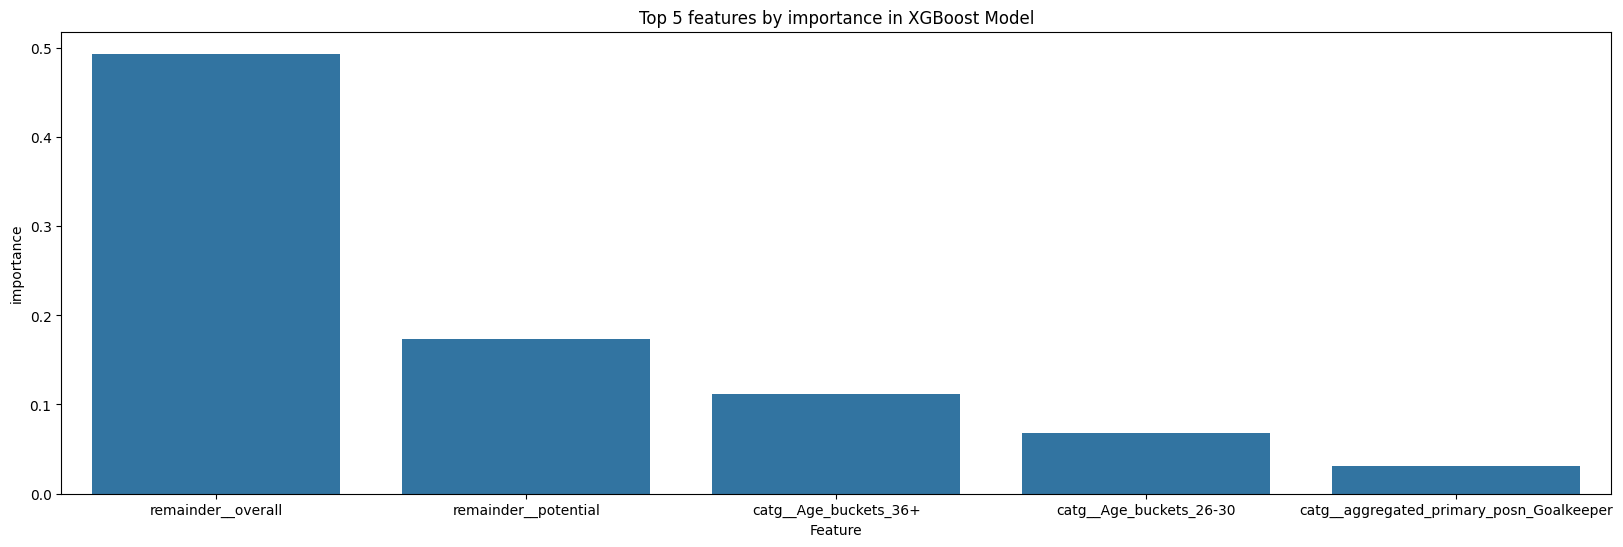

In [84]:
top_5_features_in_XGB = importance_df.head(5)
plt.figure(figsize=(20,6))
plt.title('Top 5 features by importance in XGBoost Model')
sns.barplot(top_5_features_in_XGB,x='Feature',y='importance')

### Feature importance analysis revealed that player overall rating and future potential were the dominant drivers of market value, together contributing nearly two-thirds of predictive importance. Age-related features, particularly players aged 36+, also had significant negative valuation impact, reflecting real-world transfer market dynamics